In [ ]:
!pip install wfdb scikit-learn tensorflow pandas numpy scipy matplotlib seaborn -q

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import wfdb
import ast

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from collections import Counter

print("Libraries imported successfully.")

Libraries imported successfully.


In [ ]:
DATA_PATH = "/content/drive/MyDrive/pluseguard/PTB-XL"

print("Dataset path:", DATA_PATH)
print("Path exists:", os.path.exists(DATA_PATH))

Dataset path: /content/drive/MyDrive/pluseguard/PTB-XL
Path exists: True


In [ ]:
df = pd.read_csv(
    os.path.join(DATA_PATH, "ptbxl_database.csv")
)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (21799, 28)


,ecg_id,patient_id,age,sex,height,weight,nurse,site,device,recording_date,...,validated_by_human,baseline_drift,static_noise,burst_noise,electrodes_problems,extra_beats,pacemaker,strat_fold,filename_lr,filename_hr
0,1,15709.0,56.0,1,NaN,63.0,2.0,0.0,CS-12 E,1984-11-09 09:17:34,...,True,NaN,", I-V1,",NaN,NaN,NaN,NaN,3,records100/00000/00001_lr,records500/00000/00001_hr
1,2,13243.0,19.0,0,NaN,70.0,2.0,0.0,CS-12 E,1984-11-14 12:55:37,...,True,NaN,NaN,NaN,NaN,NaN,NaN,2,records100/00000/00002_lr,records500/00000/00002_hr
2,3,20372.0,37.0,1,NaN,69.0,2.0,0.0,CS-12 E,1984-11-15 12:49:10,...,True,NaN,NaN,NaN,NaN,NaN,NaN,5,records100/00000/00003_lr,records500/00000/00003_hr
3,4,17014.0,24.0,0,NaN,82.0,2.0,0.0,CS-12 E,1984-11-15 13:44:57,...,True,", II,III,AVF",NaN,NaN,NaN,NaN,NaN,3,records100/00000/00004_lr,records500/00000/00004_hr
4,5,17448.0,19.0,1,NaN,70.0,2.0,0.0,CS-12 E,1984-11-17 10:43:15,...,True,", III,AVR,AVF",NaN,NaN,NaN,NaN,NaN,4,records100/00000/00005_lr,records500/00000/00005_hr


In [ ]:
scp_df = pd.read_csv(
    os.path.join(DATA_PATH, "scp_statements.csv"),
    index_col=0
)

print("SCP statements shape:", scp_df.shape)
scp_df.head()

SCP statements shape: (71, 12)


,description,diagnostic,form,rhythm,diagnostic_class,diagnostic_subclass,Statement Category,SCP-ECG Statement Description,AHA code,aECG REFID,CDISC Code,DICOM Code
NDT,non-diagnostic T abnormalities,1.0,1.0,NaN,STTC,STTC,other ST-T descriptive statements,non-diagnostic T abnormalities,NaN,NaN,NaN,NaN
NST_,non-specific ST changes,1.0,1.0,NaN,STTC,NST_,Basic roots for coding ST-T changes and abnorm...,non-specific ST changes,145.0,MDC_ECG_RHY_STHILOST,NaN,NaN
DIG,digitalis-effect,1.0,1.0,NaN,STTC,STTC,other ST-T descriptive statements,suggests digitalis-effect,205.0,NaN,NaN,NaN
LNGQT,long QT-interval,1.0,1.0,NaN,STTC,STTC,other ST-T descriptive statements,long QT-interval,148.0,NaN,NaN,NaN
NORM,normal ECG,1.0,NaN,NaN,NORM,NORM,Normal/abnormal,normal ECG,1.0,NaN,NaN,F-000B7


In [ ]:
print(df["filename_lr"].head())

0    records100/00000/00001_lr
1    records100/00000/00002_lr
2    records100/00000/00003_lr
3    records100/00000/00004_lr
4    records100/00000/00005_lr
Name: filename_lr, dtype: object


In [ ]:
record_path = os.path.join(
    DATA_PATH,
    df.iloc[0]["filename_lr"]
)

record = wfdb.rdrecord(record_path)

print("Signal shape:", record.p_signal.shape)
print("Sampling frequency:", record.fs)
print("Lead names:", record.sig_name)

Signal shape: (1000, 12)
Sampling frequency: 100
Lead names: ['I', 'II', 'III', 'AVR', 'AVL', 'AVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']


In [ ]:
lead_ii_index = record.sig_name.index("II")

print("Lead II index:", lead_ii_index)

Lead II index: 1


In [ ]:
lead_ii = record.p_signal[:, lead_ii_index]

print("Lead II shape:", lead_ii.shape)
print("First 10 Lead II samples:")
print(lead_ii[:10])

Lead II shape: (1000,)
First 10 Lead II samples:
[-0.055 -0.051 -0.044 -0.038 -0.031 -0.025 -0.014  0.008  0.044  0.045]


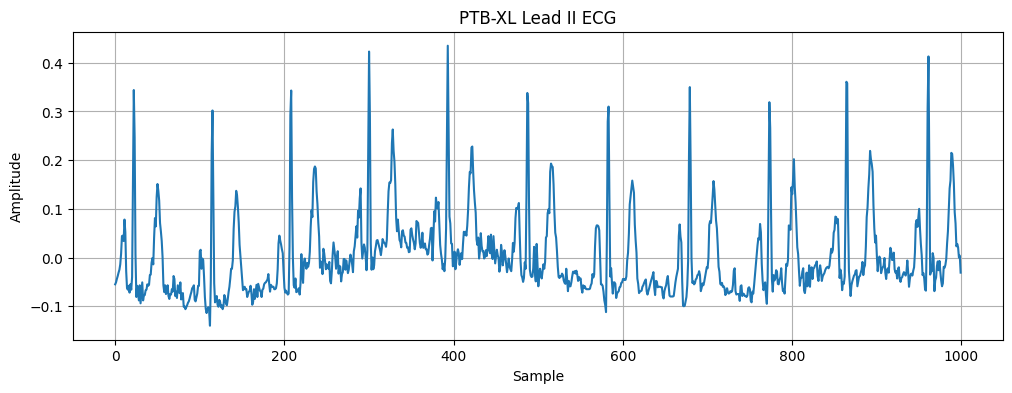

In [ ]:
plt.figure(figsize=(12, 4))

plt.plot(lead_ii)

plt.title("PTB-XL Lead II ECG")
plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.grid(True)

plt.show()

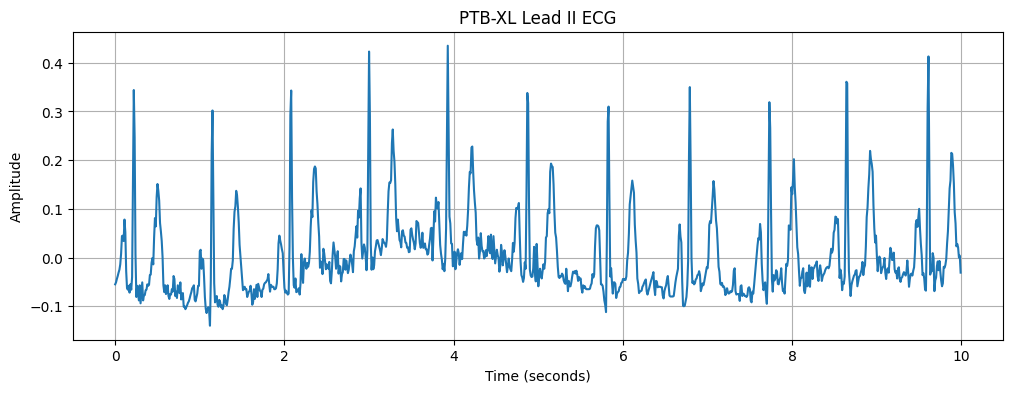

In [ ]:
time = np.arange(len(lead_ii)) / record.fs

plt.figure(figsize=(12, 4))

plt.plot(time, lead_ii)

plt.title("PTB-XL Lead II ECG")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.grid(True)

plt.show()

In [ ]:
print("Available ECG leads:")

for i, lead in enumerate(record.sig_name):
    print(i, ":", lead)

Available ECG leads:
0 : I
1 : II
2 : III
3 : AVR
4 : AVL
5 : AVF
6 : V1
7 : V2
8 : V3
9 : V4
10 : V5
11 : V6


In [ ]:
def load_lead_ii(filename):

    record_path = os.path.join(DATA_PATH, filename)

    record = wfdb.rdrecord(record_path)

    lead_ii_index = record.sig_name.index("II")

    lead_ii = record.p_signal[:, lead_ii_index]

    return lead_ii

In [ ]:
test_lead_ii = load_lead_ii(
    df.iloc[0]["filename_lr"]
)

print("Shape:", test_lead_ii.shape)
print("Mean:", np.mean(test_lead_ii))
print("Standard deviation:", np.std(test_lead_ii))

Shape: (1000,)
Mean: 0.0007230000000000016
Standard deviation: 0.08322331566934833


In [ ]:
X = []
valid_indices = []

for i, filename in enumerate(df["filename_lr"]):

    try:
        lead_ii = load_lead_ii(filename)

        X.append(lead_ii)
        valid_indices.append(i)

    except Exception as e:
        print(f"Error at index {i}: {e}")

In [ ]:
X = np.array(X)

print("X shape:", X.shape)

X shape: (21799, 1000)


In [ ]:
df = df.iloc[valid_indices].reset_index(drop=True)

print("Updated metadata shape:", df.shape)
print("ECG data shape:", X.shape)

Updated metadata shape: (21799, 28)
ECG data shape: (21799, 1000)


In [ ]:
print("Number of ECG records:", len(X))
print("Samples per ECG:", X.shape[1])
print("Lead used: Lead II")
print("Sampling frequency:", record.fs)

Number of ECG records: 21799
Samples per ECG: 1000
Lead used: Lead II
Sampling frequency: 100


In [ ]:
print("ECG data shape:", X.shape)
print("Metadata shape:", df.shape)

ECG data shape: (21799, 1000)
Metadata shape: (21799, 28)


In [ ]:
df["scp_dict"] = df["scp_codes"].apply(ast.literal_eval)

print(df["scp_dict"].head())

0    {'NORM': 100.0, 'LVOLT': 0.0, 'SR': 0.0}
1                {'NORM': 80.0, 'SBRAD': 0.0}
2                  {'NORM': 100.0, 'SR': 0.0}
3                  {'NORM': 100.0, 'SR': 0.0}
4                  {'NORM': 100.0, 'SR': 0.0}
Name: scp_dict, dtype: object


In [ ]:
mi_codes = set(
    scp_df[
        scp_df["diagnostic_class"] == "MI"
    ].index
)

print("MI codes:")
print(sorted(mi_codes))

MI codes:
['ALMI', 'AMI', 'ASMI', 'ILMI', 'IMI', 'INJAL', 'INJAS', 'INJIL', 'INJIN', 'INJLA', 'IPLMI', 'IPMI', 'LMI', 'PMI']


In [ ]:
norm_codes = set(
    scp_df[
        scp_df["diagnostic_class"] == "NORM"
    ].index
)

print("Normal codes:")
print(sorted(norm_codes))

Normal codes:
['NORM']


In [ ]:
def assign_label(scp_dict):

    # Keep only codes with a non-zero value
    active_codes = {
        code for code, value in scp_dict.items()
        if float(value) > 0
    }

    # Rule 1: If ANY active MI code is present → MI
    if len(active_codes.intersection(mi_codes)) > 0:
        return 1

    # Rule 2: NORM is the only active diagnosis → Normal
    if active_codes == {"NORM"}:
        return 0

    # Rule 3: Everything else → exclude
    return -1

In [ ]:
df["label"] = df["scp_dict"].apply(assign_label)

print(df["label"].value_counts().sort_index())

label
-1    7354
 0    8976
 1    5469
Name: count, dtype: int64


In [ ]:
normal_count = (df["label"] == 0).sum()
mi_count = (df["label"] == 1).sum()
excluded_count = (df["label"] == -1).sum()

print("Normal (0):", normal_count)
print("MI (1):", mi_count)
print("Excluded (-1):", excluded_count)

Normal (0): 8976
MI (1): 5469
Excluded (-1): 7354


In [ ]:
normal_records = df[df["label"] == 0]

print(
    normal_records[
        ["scp_codes", "scp_dict", "label"]
    ].head(10)
)

                                   scp_codes  \
0   {'NORM': 100.0, 'LVOLT': 0.0, 'SR': 0.0}   
1               {'NORM': 80.0, 'SBRAD': 0.0}   
2                 {'NORM': 100.0, 'SR': 0.0}   
3                 {'NORM': 100.0, 'SR': 0.0}   
4                 {'NORM': 100.0, 'SR': 0.0}   
5                 {'NORM': 100.0, 'SR': 0.0}   
6                 {'NORM': 100.0, 'SR': 0.0}   
8                 {'NORM': 100.0, 'SR': 0.0}   
9                 {'NORM': 100.0, 'SR': 0.0}   
10              {'NORM': 80.0, 'SARRH': 0.0}   

                                    scp_dict  label  
0   {'NORM': 100.0, 'LVOLT': 0.0, 'SR': 0.0}      0  
1               {'NORM': 80.0, 'SBRAD': 0.0}      0  
2                 {'NORM': 100.0, 'SR': 0.0}      0  
3                 {'NORM': 100.0, 'SR': 0.0}      0  
4                 {'NORM': 100.0, 'SR': 0.0}      0  
5                 {'NORM': 100.0, 'SR': 0.0}      0  
6                 {'NORM': 100.0, 'SR': 0.0}      0  
8                 {'NORM': 100.0, 'SR':

In [ ]:
mi_records = df[df["label"] == 1]

print(
    mi_records[
        ["scp_codes", "scp_dict", "label"]
    ].head(10)
)

                                             scp_codes  \
7               {'IMI': 35.0, 'ABQRS': 0.0, 'SR': 0.0}   
38   {'IMI': 15.0, 'LNGQT': 100.0, 'NST_': 100.0, '...   
49             {'LMI': 15.0, 'IVCD': 100.0, 'SR': 0.0}   
62             {'ASMI': 15.0, 'ABQRS': 0.0, 'SR': 0.0}   
76            {'AMI': 50.0, 'IRBBB': 100.0, 'SR': 0.0}   
102  {'IMI': 15.0, 'LAFB': 100.0, 'ABQRS': 0.0, 'ST...   
105  {'ASMI': 50.0, 'LVH': 15.0, 'ABQRS': 0.0, 'SR'...   
130            {'ASMI': 50.0, 'ABQRS': 0.0, 'SR': 0.0}   
138  {'IMI': 35.0, 'ISCLA': 100.0, 'SEHYP': 50.0, '...   
144         {'LMI': 50.0, 'ISCIL': 100.0, 'AFIB': 0.0}   

                                              scp_dict  label  
7               {'IMI': 35.0, 'ABQRS': 0.0, 'SR': 0.0}      1  
38   {'IMI': 15.0, 'LNGQT': 100.0, 'NST_': 100.0, '...      1  
49             {'LMI': 15.0, 'IVCD': 100.0, 'SR': 0.0}      1  
62             {'ASMI': 15.0, 'ABQRS': 0.0, 'SR': 0.0}      1  
76            {'AMI': 50.0, 'IRBBB': 100.

In [ ]:
norm_mixed = df[
    (df["scp_dict"].apply(lambda x: "NORM" in x)) &
    (df["scp_dict"].apply(lambda x: len(x) > 1))
]

print("NORM + other disease:", len(norm_mixed))

print(
    norm_mixed[
        ["scp_codes", "scp_dict", "label"]
    ].head(10)
)

NORM + other disease: 9324
                                   scp_codes  \
0   {'NORM': 100.0, 'LVOLT': 0.0, 'SR': 0.0}   
1               {'NORM': 80.0, 'SBRAD': 0.0}   
2                 {'NORM': 100.0, 'SR': 0.0}   
3                 {'NORM': 100.0, 'SR': 0.0}   
4                 {'NORM': 100.0, 'SR': 0.0}   
5                 {'NORM': 100.0, 'SR': 0.0}   
6                 {'NORM': 100.0, 'SR': 0.0}   
8                 {'NORM': 100.0, 'SR': 0.0}   
9                 {'NORM': 100.0, 'SR': 0.0}   
10              {'NORM': 80.0, 'SARRH': 0.0}   

                                    scp_dict  label  
0   {'NORM': 100.0, 'LVOLT': 0.0, 'SR': 0.0}      0  
1               {'NORM': 80.0, 'SBRAD': 0.0}      0  
2                 {'NORM': 100.0, 'SR': 0.0}      0  
3                 {'NORM': 100.0, 'SR': 0.0}      0  
4                 {'NORM': 100.0, 'SR': 0.0}      0  
5                 {'NORM': 100.0, 'SR': 0.0}      0  
6                 {'NORM': 100.0, 'SR': 0.0}      0  
8           

In [ ]:
valid_mask = df["label"].isin([0, 1])

X_filtered = X[valid_mask.values]

df_filtered = df[
    valid_mask
].reset_index(drop=True)

y = df_filtered["label"].values

In [ ]:
print("Filtered ECG shape:", X_filtered.shape)
print("Labels shape:", y.shape)
print("Metadata shape:", df_filtered.shape)

Filtered ECG shape: (14445, 1000)
Labels shape: (14445,)
Metadata shape: (14445, 30)


In [ ]:
print("Normal (0):", np.sum(y == 0))
print("MI (1):", np.sum(y == 1))

Normal (0): 8976
MI (1): 5469


In [ ]:
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X_filtered,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.125,
    random_state=42,
    stratify=y_train_val
)

In [ ]:
print("Training:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nValidation:")
print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

print("\nTesting:")
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

Training:
X_train: (10111, 1000)
y_train: (10111,)

Validation:
X_val: (1445, 1000)
y_val: (1445,)

Testing:
X_test: (2889, 1000)
y_test: (2889,)


In [ ]:
print("Training:")
print(pd.Series(y_train).value_counts().sort_index())

print("\nValidation:")
print(pd.Series(y_val).value_counts().sort_index())

print("\nTesting:")
print(pd.Series(y_test).value_counts().sort_index())

Training:
0    6283
1    3828
Name: count, dtype: int64

Validation:
0    898
1    547
Name: count, dtype: int64

Testing:
0    1795
1    1094
Name: count, dtype: int64


In [ ]:
def show_distribution(name, labels):

    counts = pd.Series(labels).value_counts().sort_index()
    percentages = counts / len(labels) * 100

    print(f"\n{name}")
    print("-" * 30)

    for label in counts.index:

        class_name = "Normal" if label == 0 else "MI"

        print(
            f"{class_name}: "
            f"{counts[label]} "
            f"({percentages[label]:.2f}%)"
        )


show_distribution("Training", y_train)
show_distribution("Validation", y_val)
show_distribution("Testing", y_test)


Training
------------------------------
Normal: 6283 (62.14%)
MI: 3828 (37.86%)

Validation
------------------------------
Normal: 898 (62.15%)
MI: 547 (37.85%)

Testing
------------------------------
Normal: 1795 (62.13%)
MI: 1094 (37.87%)


In [ ]:
train_ids = set(df_filtered.index[
    df_filtered["label"].isin(y_train)
])

In [ ]:
indices = np.arange(len(X_filtered))

train_val_idx, test_idx = train_test_split(
    indices,
    test_size=0.20,
    random_state=42,
    stratify=y
)

train_idx, val_idx = train_test_split(
    train_val_idx,
    test_size=0.20,
    random_state=42,
    stratify=y[train_val_idx]
)

X_train = X_filtered[train_idx]
y_train = y[train_idx]

X_val = X_filtered[val_idx]
y_val = y[val_idx]

X_test = X_filtered[test_idx]
y_test = y[test_idx]

In [ ]:
print("Train ∩ Validation:",
      len(set(train_idx) & set(val_idx)))

print("Train ∩ Test:",
      len(set(train_idx) & set(test_idx)))

print("Validation ∩ Test:",
      len(set(val_idx) & set(test_idx)))

Train ∩ Validation: 0
Train ∩ Test: 0
Validation ∩ Test: 0


In [ ]:
print("=" * 50)
print("FINAL DATASET SUMMARY")
print("=" * 50)

print(f"Training   : {len(X_train)} samples")
print(f"Validation : {len(X_val)} samples")
print(f"Testing    : {len(X_test)} samples")

print("\nClass labels:")
print("0 = Normal")
print("1 = MI")

print("\nTraining shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Testing shape:", X_test.shape)

print("\nNo augmentation performed.")
print("No normalization performed.")

FINAL DATASET SUMMARY
Training   : 9244 samples
Validation : 2312 samples
Testing    : 2889 samples

Class labels:
0 = Normal
1 = MI

Training shape: (9244, 1000)
Validation shape: (2312, 1000)
Testing shape: (2889, 1000)

No augmentation performed.
No normalization performed.


In [ ]:
OUTPUT_PATH = "/content/drive/MyDrive/pluseguard/Preprocessed"
os.makedirs(OUTPUT_PATH, exist_ok=True)

np.save(
    os.path.join(OUTPUT_PATH, "X_train.npy"),
    X_train
)

np.save(
    os.path.join(OUTPUT_PATH, "y_train.npy"),
    y_train
)

np.save(
    os.path.join(OUTPUT_PATH, "X_val.npy"),
    X_val
)

np.save(
    os.path.join(OUTPUT_PATH, "y_val.npy"),
    y_val
)

np.save(
    os.path.join(OUTPUT_PATH, "X_test.npy"),
    X_test
)

np.save(
    os.path.join(OUTPUT_PATH, "y_test.npy"),
    y_test
)

print("All datasets saved successfully.")

All datasets saved successfully.
